__Markus Mulvihill__

__Last updated May 2026__

# Necessary Packages and Modules

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tomllib
import plt_config

# Introduction

This file examines the accuracy and time complexity of the extended Kalman filter and the particle filter with various number of particles.

In [2]:
try:
    time_arr_03 = np.load("../scripts/variables/time_arr_03_temp.npy")
    error_arr_03 = np.load("../scripts/variables/error_arr_03_temp.npy")
    G_ests = np.load("../scripts/variables/G_ests_03_temp.npy")
    G_trues = np.load("../scripts/variables/G_trues_03_temp.npy")
    # all_vars = np.load("../scripts/saved_variables/module3/vars_03_temp.npy")
    states = np.load("../scripts/variables/states_03_temp.npy")
    print("Loaded variables")
except Exception:
    print("Run 03_Estimator_Comparison.py")

Loaded variables


In [3]:
with open("../config.toml", "rb") as f:
    cfg = tomllib.load(f)
curr_module = "03"
num_particles = cfg[curr_module]["num_particles"]
low_perc = cfg[curr_module]["low_perc"]
high_perc = cfg[curr_module]["high_perc"]
CI = cfg[curr_module]["CI"]
converge_time = cfg[curr_module]["converge_time"]
deviations = cfg[curr_module]["deviations"]
dev_perc = cfg[curr_module]["dev_perc"]
plot_particles_idx = cfg[curr_module]["plot_particles_idx"]
num_deviations = len(deviations)
num_patients = cfg[curr_module]["num_patients"]

# Plot Results

<Axes: xlabel='Estimator', ylabel='Time to run (s)'>

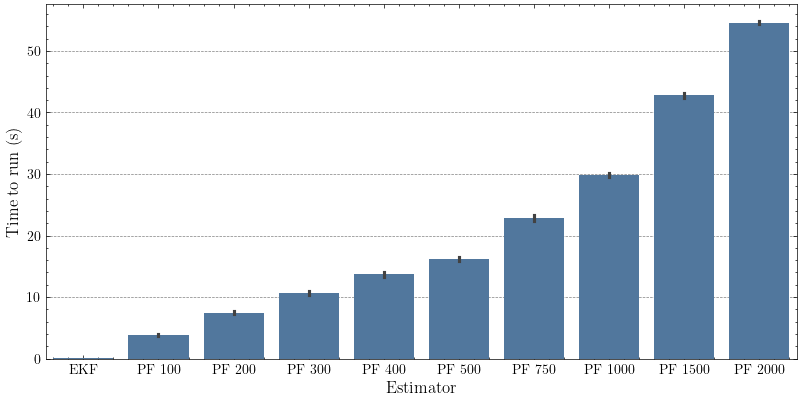

In [4]:
mean_time_run = np.average(time_arr_03[0, :, :].T, axis=0)
filters = ["EKF"]
pfs = [f"PF {particles}" for particles in num_particles]
filters.extend(pfs)
df = pd.DataFrame(time_arr_03[0, :, :].T, columns=filters).melt(
    var_name="Estimator", value_name="Time to run (s)"
)

fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(df, x="Estimator", y="Time to run (s)", ax=ax)

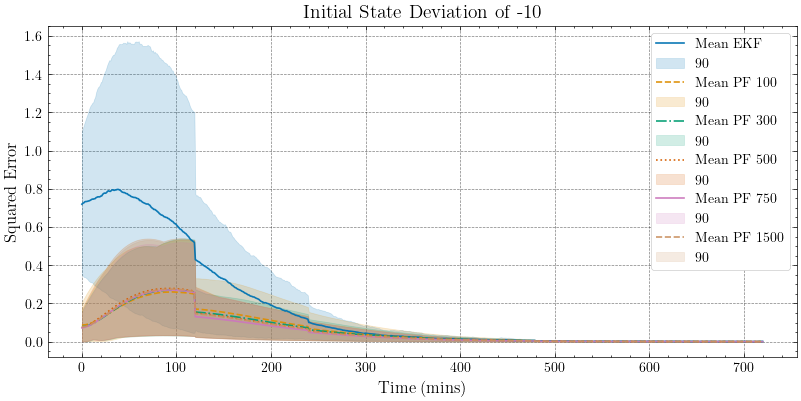

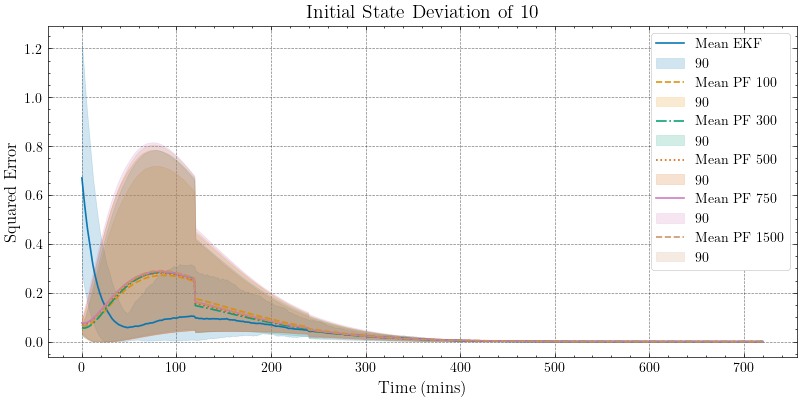

In [5]:
for j in range(num_deviations):
    mean_err = np.mean(error_arr_03[j, :, :, :], axis=1)
    ci_low = np.percentile(error_arr_03[j, :, :, :], low_perc, axis=1)
    ci_high = np.percentile(error_arr_03[j, :, :, :], high_perc, axis=1)
    time = np.arange(mean_err.shape[1])
    num_plots = len(plot_particles_idx)  #
    num_filters = len(filters)
    palette = sns.color_palette("colorblind", num_filters)

    # fig, ax = plt.subplots(2,1, sharex='col', sharey=True, figsize=(12,5))
    fig, ax = plt.subplots(figsize=(8,4))

    for i in range(num_plots):
        plot_idx = plot_particles_idx[i]
        ax.plot(
            time,
            mean_err[plot_idx],
            color=palette[i],
            linewidth=1.2,
            alpha=0.95,
            linestyle=["-", "--", "-.", ":"][i % 4],
            label=f"Mean {filters[plot_idx]}",
        )
        ax.fill_between(
            time,
            ci_low[plot_idx],
            ci_high[plot_idx],
            color=palette[i],
            alpha=0.18,
            label=f"{CI}% CI",
        )
    ax.set_ylabel("Squared Error")
    ax.legend(loc="best")
    ax.set_xlabel("Time (mins)")
    ax.set_title(f"Initial State Deviation of {dev_perc[j]} %")

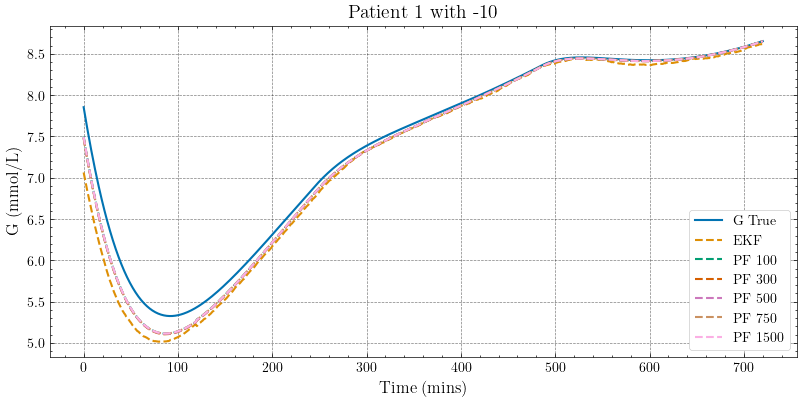

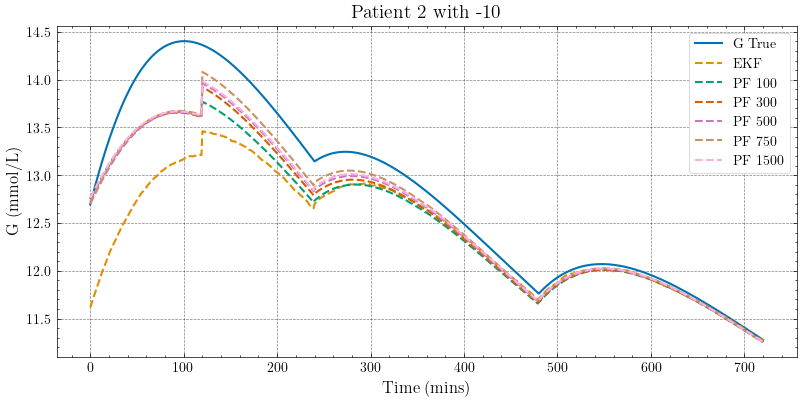

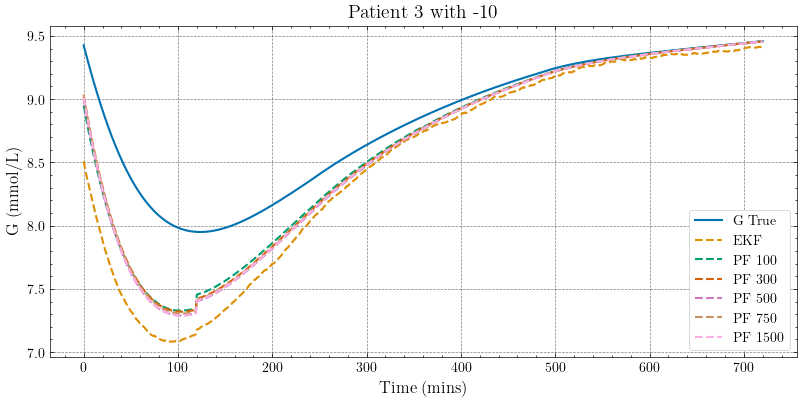

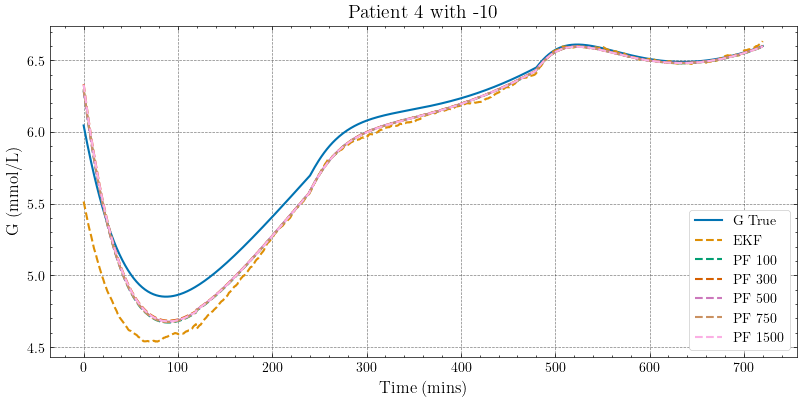

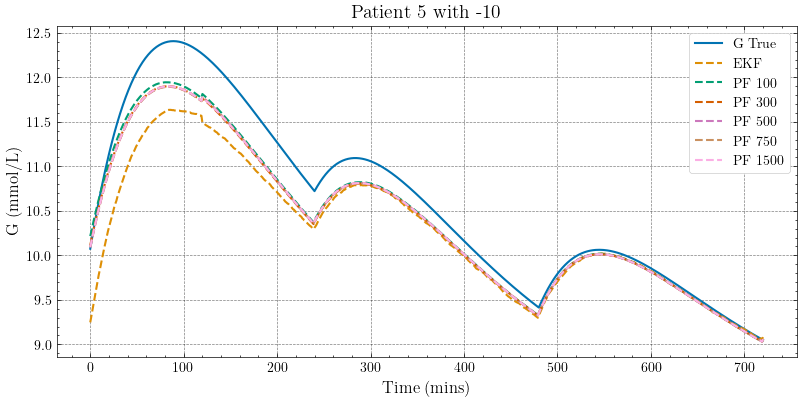

In [9]:
deviation = 0
palette = sns.color_palette("colorblind", num_filters + 1)
for i in range(5):
    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(time, G_trues[i, :], color=palette[0], label="G True")
    for j in range(num_plots):
        plot_idx = plot_particles_idx[j]
        # G_est = states[deviation, plot_idx, i, :, 2]
        G_est = G_ests[deviation, plot_idx, i, :]
        #G_std = np.sqrt(all_vars[deviation, plot_idx, i, :, 0, 0])
        ax.plot(
            time,
            G_est,
            linestyle="--",
            color=palette[j + 1],
            label=f"{filters[plot_idx]}",
        )
        
    ax.set_title(f"Patient {i + 1} with {dev_perc[deviation]} % deviation")
    ax.legend()
    ax.set_xlabel("Time (mins)")
    ax.set_ylabel("G (mmol/L)")

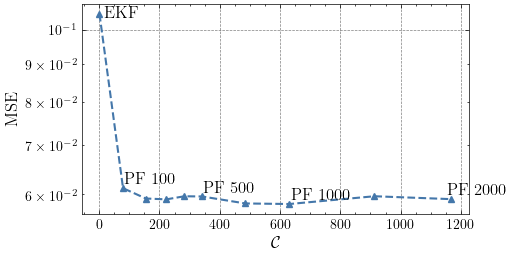

In [7]:
total_avg_time = np.average(time_arr_03, axis=(0, 2))
complexity = total_avg_time / min(total_avg_time)
total_avg_err = np.average(error_arr_03, axis=(0, 2, 3))

fig, ax = plt.subplots(figsize=(5.1,2.55))
ax.semilogy(complexity, total_avg_err, linestyle="--", marker="^")
ax.set_xlabel(r"$\mathcal{C}$")
ax.set_ylabel("MSE")
for x, y, label in zip(complexity, total_avg_err, filters):
    if label in {"EKF", "PF 100", "PF 500", "PF 1000", "PF 2000"}:
        if label == "EKF":
            ax.annotate(label, xy=(x, y), xytext=(3,-5), textcoords="offset points", ha="left", va="bottom")
        elif label == "PF 2000":
            ax.annotate(label, xy=(x, y), xytext=(-3,1), textcoords="offset points", ha="left", va="bottom")
        else:
            ax.annotate(label, xy=(x, y), xytext=(1,1), textcoords="offset points", ha="left", va="bottom")
fig.savefig("figures/5_6.pdf", format="pdf")

In [8]:
print("Total average complexity: \n", complexity)
print("Total average MSE: \n", total_avg_err)

deviation_error = np.average(error_arr_03, axis=(2,3))
deviation_std = np.std(error_arr_03, axis=(2,3))
# print("MSE per deviation: \n", deviation_error)
print("SD per deviation: \n", deviation_std)

Total average complexity: 
 [1.00000000e+00 7.92421710e+01 1.54656792e+02 2.22783200e+02
 2.82922288e+02 3.41503970e+02 4.85073336e+02 6.30752734e+02
 9.13188573e+02 1.16795552e+03]
Total average MSE: 
 [0.10512581 0.0611257  0.05919583 0.05903877 0.05960884 0.05956992
 0.05829154 0.05818933 0.05961276 0.05907879]
SD per deviation: 
 [[0.34435793 0.12011493 0.1172066  0.11598575 0.11386667 0.11961623
  0.11366609 0.11277741 0.11749842 0.11635518]
 [0.10460106 0.13638261 0.14592174 0.1456951  0.15636056 0.14652587
  0.15433176 0.15269306 0.15135492 0.15264209]]
